In [1]:
import pandas as pd

df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [2]:
df.shape

(89220, 31)

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,1


In [5]:
df["Class"].value_counts()

,count
Class,
0.0,89008
1.0,211


In [6]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,1


In [8]:
df = df.dropna()

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train, y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

Before SMOTE: Class
0.0    71206
1.0      169
Name: count, dtype: int64
After SMOTE: Class
0.0    71206
1.0    71206
Name: count, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_resampled, y_train_resampled)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, random_state=42)

model.fit(X_train_resampled, y_train_resampled)

print("Model training completed!")

Model training completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled, y_train_resampled)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [19]:
y_pred = model.predict(X_test_scaled)

print("Predictions completed!")

Predictions completed!


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[17650   152]
 [    3    39]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     17802
         1.0       0.20      0.93      0.33        42

    accuracy                           0.99     17844
   macro avg       0.60      0.96      0.67     17844
weighted avg       1.00      0.99      0.99     17844



In [21]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9794558931313229


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

print("Random Forest training completed!")

Random Forest training completed!


In [23]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Confusion Matrix:
[[17796     6]
 [    4    38]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     17802
         1.0       0.86      0.90      0.88        42

    accuracy                           1.00     17844
   macro avg       0.93      0.95      0.94     17844
weighted avg       1.00      1.00      1.00     17844



In [25]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC Score:", rf_roc_auc)

Random Forest ROC-AUC Score: 0.9735055183740725


In [26]:
import joblib

joblib.dump(rf_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [27]:
import os

print(os.listdir("/content"))

['.config', 'creditcard.csv', 'scaler.pkl', 'fraud_detection_model.pkl', 'sample_data']


In [28]:
import os

os.makedirs("/content/Credit-Card-Fraud-Detection", exist_ok=True)

print("Project folder created!")

Project folder created!


In [29]:
import shutil

shutil.copy(
    "/content/fraud_detection_model.pkl",
    "/content/Credit-Card-Fraud-Detection/"
)

shutil.copy(
    "/content/scaler.pkl",
    "/content/Credit-Card-Fraud-Detection/"
)

print("Model files copied successfully!")

Model files copied successfully!


In [30]:
readme = """
# Credit Card Fraud Detection

## Project Overview
A machine learning project that detects fraudulent credit card transactions using classification algorithms.

## Objectives
- Detect fraudulent transactions
- Handle highly imbalanced data using SMOTE
- Compare Logistic Regression and Random Forest
- Evaluate models using Precision, Recall, F1-score and ROC-AUC

## Machine Learning Models
1. Logistic Regression
2. Random Forest Classifier

## Best Model
Random Forest achieved:
- Precision: 0.86
- Recall: 0.90
- F1-score: 0.88
- ROC-AUC: 0.9735

## Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Imbalanced-learn
- Matplotlib
- Seaborn
- Google Colab

## Dataset
Credit Card Fraud Detection dataset.

## Project Workflow
Data Loading → Data Cleaning → Train/Test Split → SMOTE → Feature Scaling → Model Training → Evaluation → Model Saving
"""

with open("/content/Credit-Card-Fraud-Detection/README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [31]:
requirements = """
pandas
numpy
scikit-learn
imbalanced-learn
matplotlib
seaborn
joblib
"""

with open("/content/Credit-Card-Fraud-Detection/requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [32]:
gitignore = """
creditcard.csv
__pycache__/
.ipynb_checkpoints/
"""

with open("/content/Credit-Card-Fraud-Detection/.gitignore", "w") as f:
    f.write(gitignore.strip())

print(".gitignore created successfully!")

.gitignore created successfully!


In [33]:
import os

print(os.listdir("/content/Credit-Card-Fraud-Detection"))

['.gitignore', 'scaler.pkl', 'requirements.txt', 'README.md', 'fraud_detection_model.pkl']


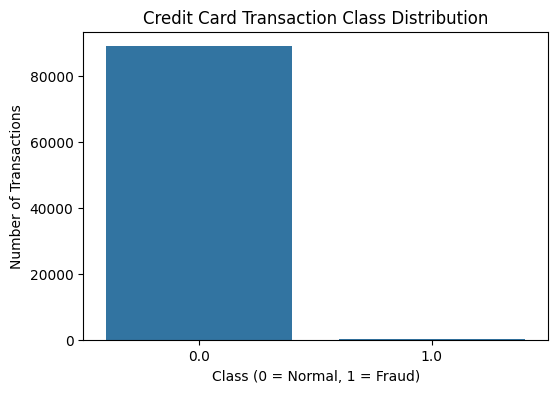

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Credit Card Transaction Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

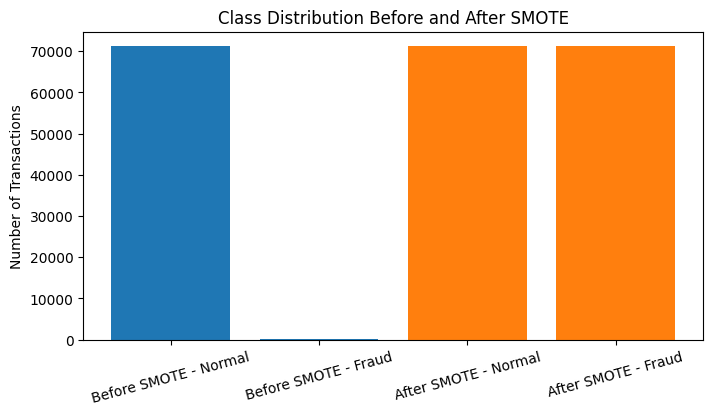

In [35]:
import matplotlib.pyplot as plt

before = y_train.value_counts()
after = y_train_resampled.value_counts()

plt.figure(figsize=(8, 4))

plt.bar(["Before SMOTE - Normal", "Before SMOTE - Fraud"],
        [before[0], before[1]])

plt.bar(["After SMOTE - Normal", "After SMOTE - Fraud"],
        [after[0], after[1]])

plt.title("Class Distribution Before and After SMOTE")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=15)

plt.show()

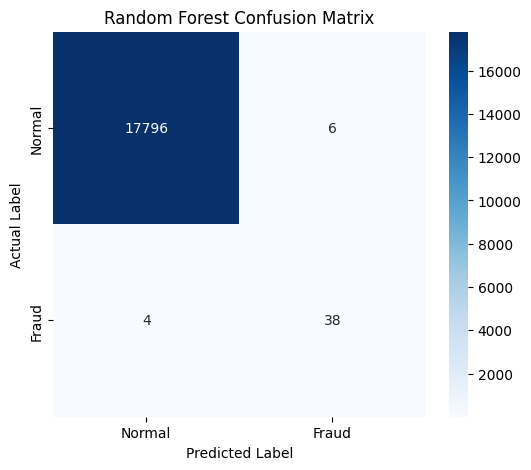

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

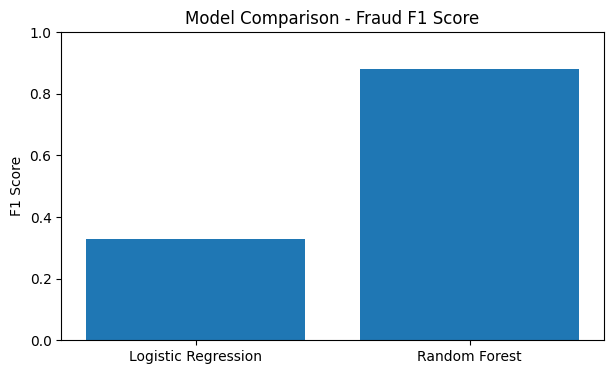

In [37]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
f1_scores = [0.33, 0.88]

plt.figure(figsize=(7, 4))
plt.bar(models, f1_scores)

plt.title("Model Comparison - Fraud F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)

plt.show()

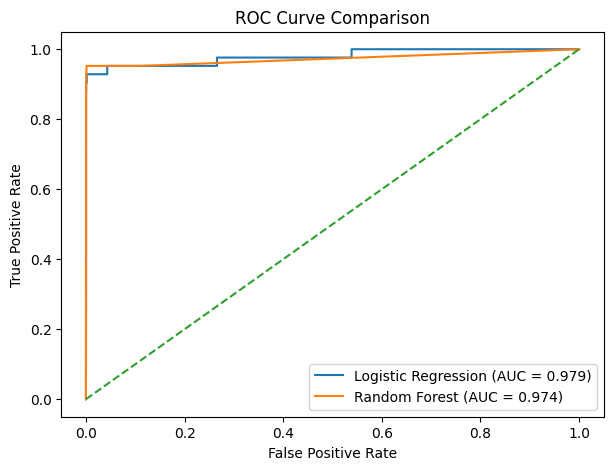

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()